In [ ]:
import pickle
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score, average_precision_score

In [3]:
with open('catboost_baseline.pkl', 'rb') as f:
    art = pickle.load(f)

# в пикле лежит словарь, а не сама модель
print('Ключи артефакта:', list(art.keys()))

# достаём что нужно
model = art['model']
feature_names = art['feature_cols']

Ключи артефакта: ['model', 'feature_cols', 'metrics_cv', 'preprocessing', 'versions']


In [4]:
print(type(model))

<class 'catboost.core.CatBoostClassifier'>


In [ ]:
feature_names[:10]

['metro_500m',
 'metro_1000m',
 'nearest_metro',
 'bus_stops_500m',
 'bus_stops_1000m',
 'nearest_bus_stops',
 'malls_500m',
 'malls_1000m',
 'nearest_malls',
 'business_centres_500m']

In [11]:
df = pd.read_csv('grid_features.csv')
df['target'] = (df['atm_count'] > 0).astype(int)

drop_cols = [
    'atm_count', 'sber_count', 'tinkoff_count', 'vtb_count',
    'alfa_count', 'gazprom_count', 'raiff_count',
    'lat', 'lon', 'target'
]

feature_cols_from_data = [c for c in df.columns if c not in drop_cols and c != 'city']

X = df[feature_cols_from_data].copy()
y = df['target'].values
groups = df['city'].values

X = X.fillna(0)

In [12]:
model = art['model']
feature_cols = art['feature_cols']

X = X[feature_cols]

In [16]:
logo = LeaveOneGroupOut()

folds = list(logo.split(X, y, groups))

train_idx, test_idx = folds[-1]

test_city = groups[test_idx[0]]

X_test = X.iloc[test_idx].copy()
y_test = y[test_idx]

print('Тестовый город:', test_city)
print('Размер теста:', X_test.shape)
print('Доля класса 1:', y_test.mean())
proba = model.predict_proba(X_test)[:, 1]

pred_df = X_test.copy()
pred_df['y_true'] = y_test
pred_df['proba_1'] = proba
pred_df['proba_0'] = 1 - proba
pred_df['city'] = test_city

Тестовый город: Санкт-Петербург
Размер теста: (135252, 90)
Доля класса 1: 0.009485996510217963


Были отобраны 30 наблюдений на основе значений вероятностей, предсказанных CatBoost. В выборку вошли 10 объектов с наиболее уверенным прогнозом класса 1, 10 объектов с наиболее уверенным прогнозом класса 0 и 10 объектов с вероятностью, наиболее близкой к 0.5. Первые две группы позволяют проанализировать случаи, в которых модель практически не сомневается в своем решении, а третья группа представляет пограничные объекты, для которых классификация наиболее затруднена. Данная выборка будет использоваться для дальнейшего анализа вклада признаков с помощью SHAP и исследования устойчивости модели к изменениям входных данных.


In [17]:
top_class1 = pred_df.sort_values('proba_1', ascending=False).head(10)

top_class0 = pred_df.sort_values('proba_1', ascending=True).head(10)

uncertain = (
    pred_df
    .assign(distance_to_05=lambda x: abs(x['proba_1'] - 0.5))
    .sort_values('distance_to_05')
    .head(10)
)

analysis_df = pd.concat([
    top_class1.assign(group='confident_class_1'),
    top_class0.assign(group='confident_class_0'),
    uncertain.assign(group='uncertain')
])

analysis_df[['y_true', 'proba_0', 'proba_1', 'group']]

,y_true,proba_0,proba_1,group
144417,1,0.001166,0.998834,confident_class_1
148100,1,0.001586,0.998414,confident_class_1
141051,1,0.001680,0.998320,confident_class_1
143797,1,0.002270,0.997730,confident_class_1
149929,1,0.002686,0.997314,confident_class_1
144103,1,0.002784,0.997216,confident_class_1
135857,1,0.002963,0.997037,confident_class_1
147466,1,0.002978,0.997022,confident_class_1
141973,1,0.003036,0.996964,confident_class_1
140462,1,0.003062,0.996938,confident_class_1


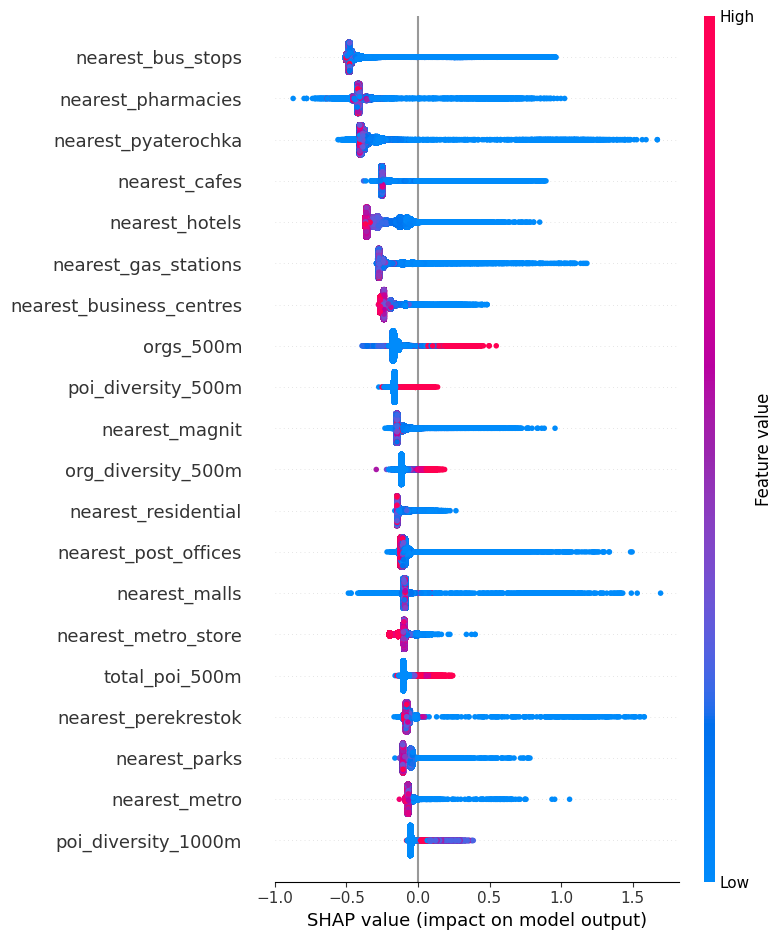

In [18]:
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

верху расположены наиболее важные факторы. Наибольшее влияние на прогноз оказывают расстояния до остановок общественного транспорта, аптек, магазинов «Пятёрочка», кафе, гостиниц и автозаправочных станций.

для большинства признаков типа `nearest_*` меньшие значения расстояния (объекты расположены ближе) увеличивают вероятность наличия банкомата, тогда как большие расстояния снижают её. 

важную роль играют показатели насыщенности территории объектами инфраструктуры (`orgs_500m`, `poi_diversity_500m`, `total_poi_500m`). Высокие значения этих признаков, как правило, положительно влияют на прогноз класса 1

Полученные результаты свидетельствуют о том, что модель в первую очередь ориентируется на доступность транспортной инфраструктуры, торговых объектов и общую плотность точек интереса вокруг рассматриваемой локации.


In [19]:
shap_importance = (
    pd.Series(
        np.abs(shap_values.values).mean(axis=0),
        index=X_test.columns
    )
    .sort_values(ascending=False)
)

shap_importance.head(20)

nearest_bus_stops           0.455056
nearest_pharmacies          0.408227
nearest_pyaterochka         0.366785
nearest_cafes               0.242477
nearest_hotels              0.228464
nearest_gas_stations        0.221200
nearest_business_centres    0.202512
orgs_500m                   0.159427
poi_diversity_500m          0.153405
nearest_magnit              0.123326
org_diversity_500m          0.112321
nearest_residential         0.102472
nearest_post_offices        0.100039
nearest_malls               0.094419
nearest_metro_store         0.091522
total_poi_500m              0.091430
nearest_perekrestok         0.071137
nearest_parks               0.070842
nearest_metro               0.062441
poi_diversity_1000m         0.058420
dtype: float64

index: 144417
group: confident_class_1
proba_1: 0.9988341992776915


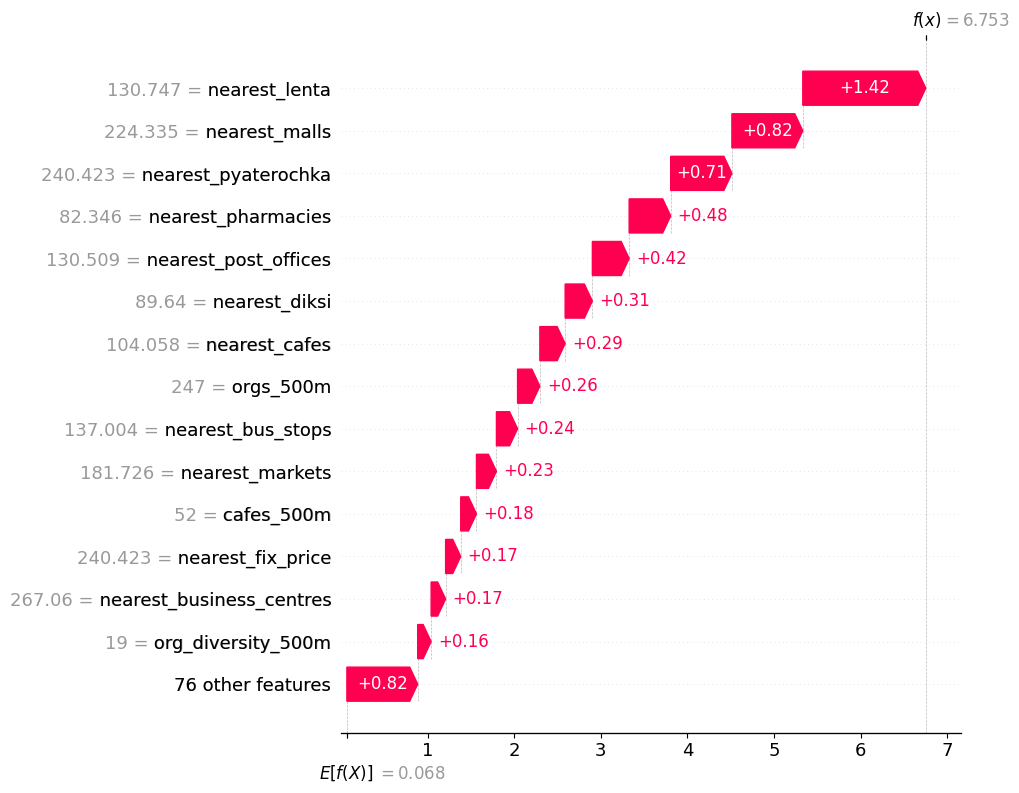

index: 148100
group: confident_class_1
proba_1: 0.9984136750527438


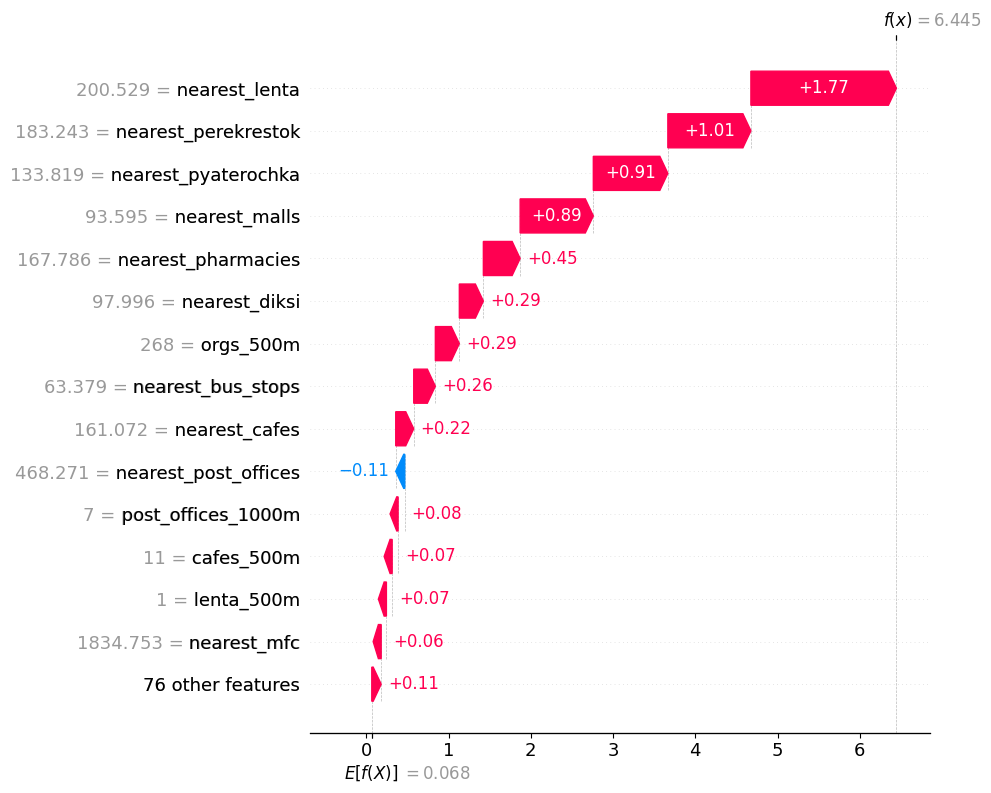

index: 141051
group: confident_class_1
proba_1: 0.998319996091146


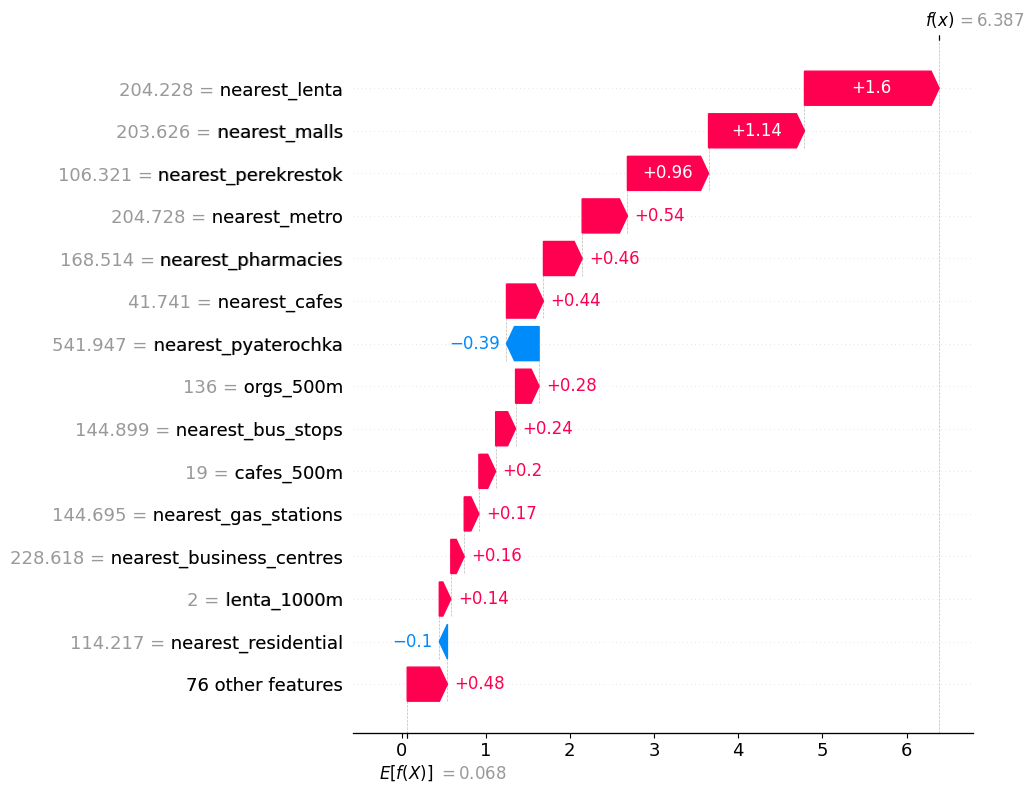

In [20]:
for idx in analysis_df.index[:3]:
    print('index:', idx)
    print('group:', analysis_df.loc[idx, 'group'])
    print('proba_1:', analysis_df.loc[idx, 'proba_1'])
    
    pos = X_test.index.get_loc(idx)
    shap.plots.waterfall(shap_values[pos], max_display=15)

Объект 144417
Вероятность класса 1: 0.9988
Истинный класс: 1


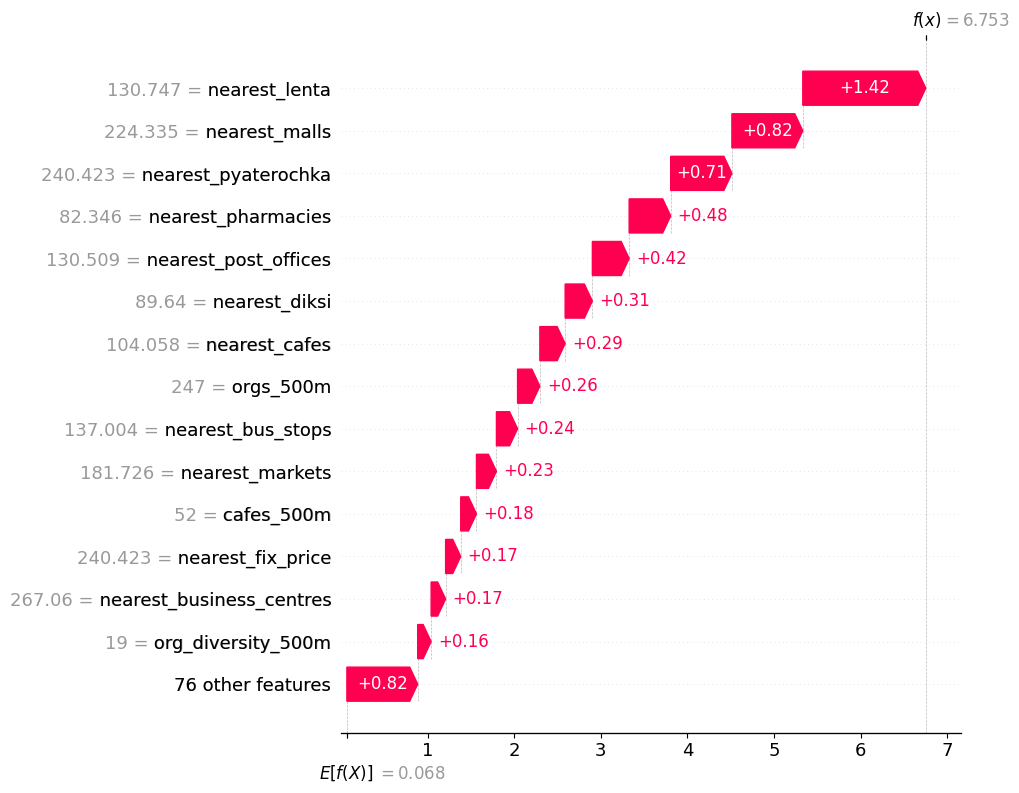

Объект 94639
Вероятность класса 1: 0.0075
Истинный класс: 0


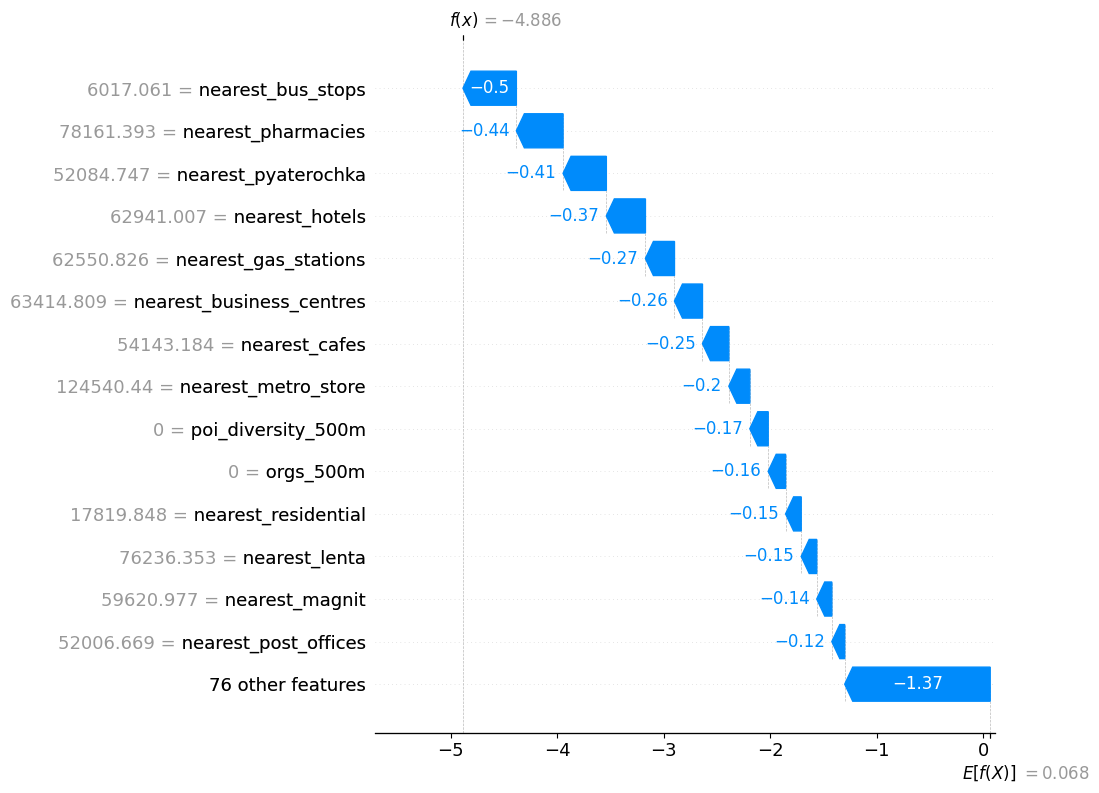

Объект 183111
Вероятность класса 1: 0.5000
Истинный класс: 0


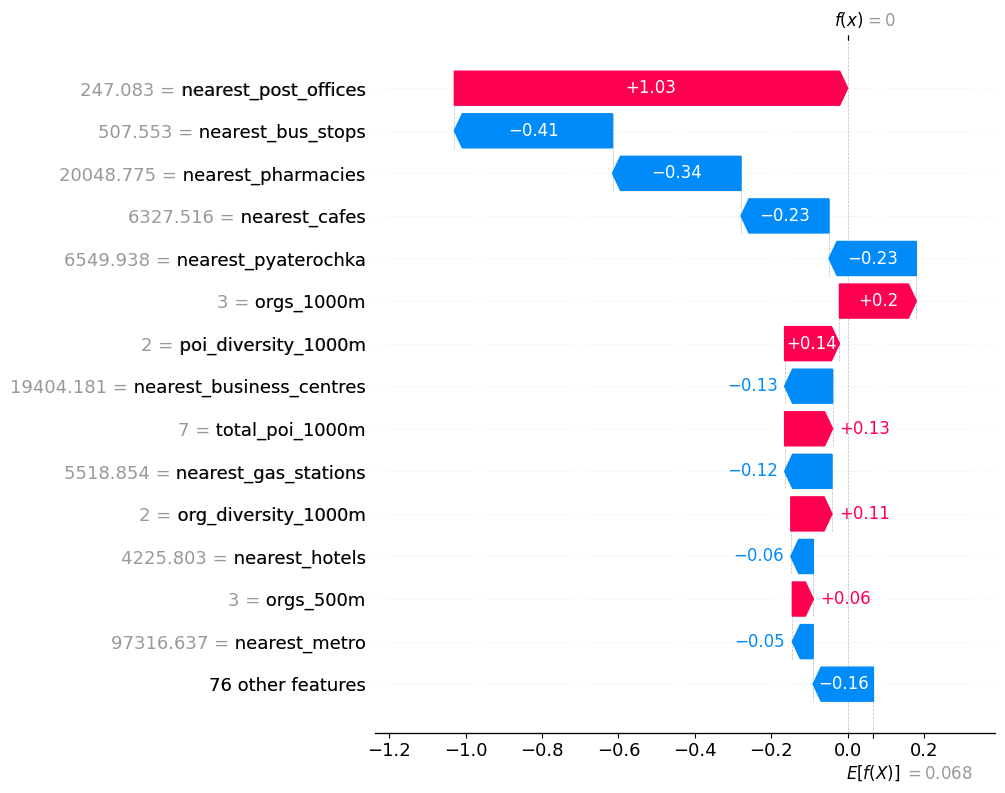

In [ ]:
idx_class1 = top_class1.index[0]
idx_class0 = top_class0.index[0]

idx_uncertain = uncertain.index[0]
for idx in [idx_class1, idx_class0, idx_uncertain]:

    print(f'Объект {idx}')
    print(f'Вероятность класса 1: {pred_df.loc[idx, "proba_1"]:.4f}')
    print(f'Истинный класс: {pred_df.loc[idx, "y_true"]}')

    shap.plots.waterfall(
        shap_values[X_test.index.get_loc(idx)],
        max_display=15
    )

Анализ SHAP-пояснений показал, что модель принимает решения преимущественно на основе характеристик окружающей инфраструктуры. Для объекта с высокой вероятностью наличия банкомата (99.88%) ключевыми факторами стали близость крупных торговых объектов, аптек, кафе, остановок общественного транспорта и высокая концентрация организаций поблизости. Для объекта с низкой вероятностью (0.75%) наблюдается обратная ситуация: большинство значимых объектов инфраструктуры расположены далеко, а плотность деловой активности низкая. Для пограничного объекта (50%) положительные и отрицательные факторы практически компенсируют друг друга: близость отдельных объектов инфраструктуры повышает вероятность размещения банкомата, однако удалённость от других важных точек притяжения снижает её. 



Выбранные признаки features изменяет одним из способов:
- zero — зануляет признаки
- x100 — увеличивает значения в 100 раз
- div100 — уменьшает значения в 100 раз
- median — заменяет значения признаков на медиану

In [25]:
def stress_test(X_base, model, base_proba, features, mode):
    X_mod = X_base.copy()
    
    if mode == 'zero':
        X_mod[features] = 0
        
    elif mode == 'x100':
        X_mod[features] = X_mod[features] * 100
        
    elif mode == 'div100':
        X_mod[features] = X_mod[features] / 100
        
    elif mode == 'median':
        for col in features:
            X_mod[col] = X_mod[col].median()
            
    else:
        raise ValueError('Unknown mode')
    
    new_proba = model.predict_proba(X_mod)[:, 1]
    
    return {
        'mode': mode,
        'features': ', '.join(features),
        'n_features': len(features),
        'mean_proba_before': base_proba.mean(),
        'mean_proba_after': new_proba.mean(),
        'mean_abs_delta': np.mean(np.abs(new_proba - base_proba)),
        'max_abs_delta': np.max(np.abs(new_proba - base_proba)),
        'changed_class_share': np.mean((new_proba >= 0.5) != (base_proba >= 0.5))
    }
top_1 = [shap_importance.index[0]]
top_5 = list(shap_importance.head(5).index)

middle_10 = list(
    shap_importance
    .iloc[len(shap_importance)//2 : len(shap_importance)//2 + 10]
    .index
)

results = []

for mode in ['zero', 'x100', 'div100', 'median']:
    results.append(stress_test(X_test, model, proba, top_1, mode))


results.append(stress_test(X_test, model, proba, top_5, 'zero'))
results.append(stress_test(X_test, model, proba, middle_10, 'zero'))

stress_results = pd.DataFrame(results)
stress_results

,mode,features,n_features,mean_proba_before,mean_proba_after,mean_abs_delta,max_abs_delta,changed_class_share
0,zero,nearest_bus_stops,1,0.05379,0.199603,0.145936,0.506259,0.025035
1,x100,nearest_bus_stops,1,0.05379,0.048421,0.005542,0.459967,0.005286
2,div100,nearest_bus_stops,1,0.05379,0.189923,0.136256,0.490896,0.024650
3,median,nearest_bus_stops,1,0.05379,0.048419,0.005544,0.459967,0.005286
4,zero,"nearest_bus_stops, nearest_pharmacies, nearest...",5,0.05379,0.790375,0.736589,0.870477,0.982588
5,zero,"bus_stops_500m, residential_1000m, total_level...",10,0.05379,0.053912,0.000937,0.270490,0.000887


модель является устойчивой к изменению признаков средней важности, однако крайне чувствительна к наиболее значимым факторам. Наибольшее влияние оказывает близость остановок общественного транспорта и других объектов инфраструктуры. Зануление пяти наиболее важных признаков привело к изменению класса у 98% наблюдений, тогда как удаление десяти признаков средней важности практически не повлияло на результаты. Это подтверждает, что модель концентрирует основную часть предсказательной силы в ограниченном наборе наиболее информативных признаков, связанных с транспортной доступностью и городской инфраструктурой.